# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
#vizualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder #to work with categorical features in our dataset
from imblearn.over_sampling import SMOTE #since our dataset has class imbalance,we need Synthetic Minority Oversampling Technique.
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV #for hyperparameter tuning,and instead of relying on one accuracy score we will use cross_val score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle #save model

# **Data Pre-Processing**

In [ ]:
df=pd.read_csv('autism_dataset.csv')

In [3]:
df.shape

(800, 22)

In [4]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,1,1,1,0,1,1,...,f,White-European,no,no,United States,no,7.819715,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,f,South Asian,no,no,Australia,no,10.544296,18 and more,?,0
2,3,1,1,1,1,1,1,0,0,1,...,f,White-European,no,no,United Kingdom,no,13.167506,18 and more,Self,1
3,4,0,0,0,1,0,0,0,0,0,...,f,South Asian,no,no,New Zealand,no,1.530098,18 and more,?,0
4,5,0,0,0,0,1,0,0,0,1,...,m,Black,no,yes,Italy,no,7.949723,18 and more,Self,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [6]:
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.00000,800.000000,800.00000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.582500,0.28625,0.321250,0.41500,0.457500,0.20875,0.273750,0.717500,0.316250,0.460000,28.612306,7.058530,0.231250
std,231.0844,0.493455,0.45229,0.467249,0.49303,0.498502,0.40667,0.446161,0.450497,0.465303,0.498709,12.872373,3.788969,0.421896
min,1.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,9.560505,-2.594654,0.000000
25%,200.7500,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,19.282082,4.527556,0.000000
50%,400.5000,1.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,25.479960,6.893472,0.000000
75%,600.2500,1.000000,1.00000,1.000000,1.00000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,33.154755,9.892981,0.000000
max,800.0000,1.000000,1.00000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,72.402488,13.390868,1.000000


In [7]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [8]:
pd.set_option('display.max_columns',None)

In [9]:
df.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,1,1,1,1,1,1,1,1,1,1,42.084907,f,White-European,no,yes,United States,no,13.390868,18 and more,Self,1
796,797,1,1,0,0,1,0,0,0,1,1,17.669291,f,Asian,no,no,New Zealand,no,9.454201,18 and more,Self,0
797,798,0,0,0,0,0,0,1,0,1,1,18.242557,m,White-European,yes,no,Jordan,no,6.805509,18 and more,Self,1
798,799,1,1,1,1,1,1,0,1,1,1,19.241473,f,Middle Eastern,no,yes,United States,no,3.682732,18 and more,Relative,0
799,800,1,0,0,1,1,0,0,1,1,1,32.170098,f,Asian,no,no,New Zealand,no,12.060168,18 and more,Self,0


Age data type needs to be in Integer instead of float.


In [10]:
df['age']=df['age'].astype(int)

In [11]:
df.tail(3)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
797,798,0,0,0,0,0,0,1,0,1,1,18,m,White-European,yes,no,Jordan,no,6.805509,18 and more,Self,1
798,799,1,1,1,1,1,1,0,1,1,1,19,f,Middle Eastern,no,yes,United States,no,3.682732,18 and more,Relative,0
799,800,1,0,0,1,1,0,0,1,1,1,32,f,Asian,no,no,New Zealand,no,12.060168,18 and more,Self,0


In [12]:
# Find unique values for all columns except for the numerical ones
for col in df.columns:
  num_cols=['ID','age','result']
  if col not in num_cols:
    print(col,df[col].unique())
    print()

A1_Score [1 0]

A2_Score [0 1]

A3_Score [1 0]

A4_Score [1 0]

A5_Score [1 0]

A6_Score [1 0]

A7_Score [0 1]

A8_Score [1 0]

A9_Score [1 0]

A10_Score [1 0]

gender ['f' 'm']

ethnicity ['White-European' 'South Asian' 'Black' 'Asian' 'Middle Eastern ' '?'
 'others' 'Latino' 'Turkish' 'Others' 'Hispanic' 'Pasifika']

jaundice ['no' 'yes']

austim ['no' 'yes']

contry_of_res ['United States' 'Australia' 'United Kingdom' 'New Zealand' 'Italy'
 'Nicaragua' 'Canada' 'United Arab Emirates' 'Netherlands' 'Sri Lanka'
 'India' 'Armenia' 'Sierra Leone' 'Argentina' 'Azerbaijan' 'Iceland'
 'Egypt' 'Serbia' 'Afghanistan' 'Costa Rica' 'Jordan' 'Angola' 'Pakistan'
 'Brazil' 'Ireland' 'Kazakhstan' 'Viet Nam' 'Ethiopia' 'Austria' 'Finland'
 'France' 'Malaysia' 'Japan' 'Spain' 'Philippines' 'Iran' 'Czech Republic'
 'Russia' 'Romania' 'Mexico' 'Belgium' 'Aruba' 'Uruguay' 'Indonesia'
 'Ukraine' 'AmericanSamoa' 'Germany' 'China' 'Iraq' 'Tonga' 'South Africa'
 'Saudi Arabia' 'Hong Kong' 'Bahamas' 'Ecuado

**What did we conclude here?**
* In column ethnicity, we have a ? value that needs to be handled separately, also 'others' and 'Others' are written as separate category.
* In age_desc we have only one value
* Relation Column also has a ? category, also all unique values can be boiled down to : Self and Others,base on who took the test.

In [13]:
# Dropping irrelevant columns
df=df.drop(columns=['ID','age_desc'])

In [14]:
df.shape

(800, 20)

In [15]:
# check target class distribution
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,615
1,185


Insight: We have a class imbalance in target class



# **Exploratory Data Analysis**

### Univariate analysis

For Numerical Columns:
- age
- result

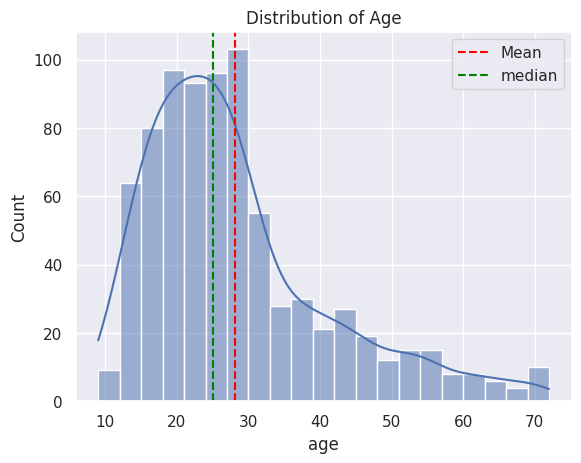

In [16]:
from matplotlib.lines import lineStyles
# creating histplot for age
sns.set_theme(style='darkgrid')
sns.histplot(df['age'],kde=True)
mean_age=df['age'].mean()
median_age=df['age'].median()
plt.axvline(mean_age,color='red',linestyle='dashed',label='Mean')
plt.axvline(median_age,color='green',linestyle='dashed',label='median')
plt.title('Distribution of Age')
plt.legend()
plt.show()

Observation: Data is `right skewed`, so mean will be more than median.

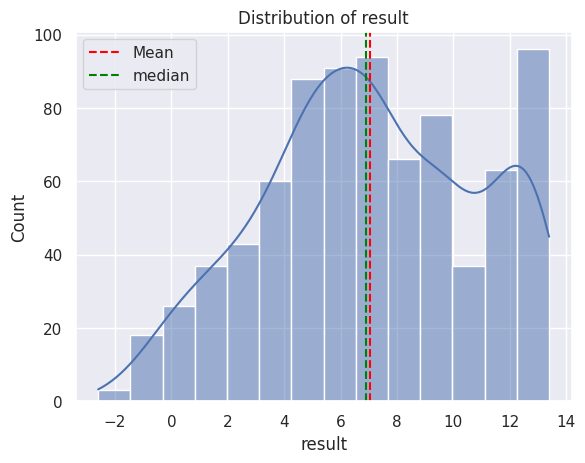

In [17]:
from matplotlib.lines import lineStyles
# creating histplot for result
sns.set_theme(style='darkgrid')
sns.histplot(df['result'],kde=True)
mean_result=df['result'].mean()
median_result=df['result'].median()
plt.axvline(mean_result,color='red',linestyle='dashed',label='Mean')
plt.axvline(median_result,color='green',linestyle='dashed',label='median')
plt.title('Distribution of result')
plt.legend()
plt.show()

Creating Boxplots and finding Outliers. As we see that max values of age and result is many times larger than their mean values.

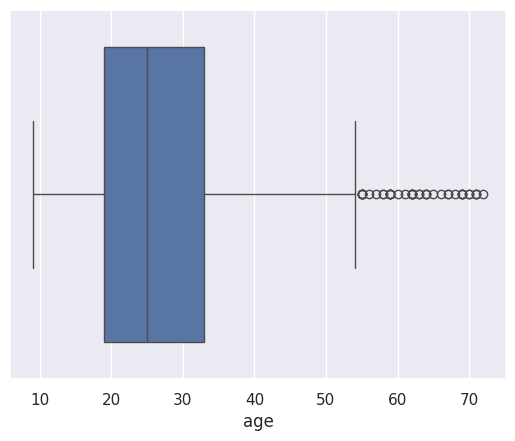

In [18]:
sns.boxplot(x=df['age'])
plt.show()

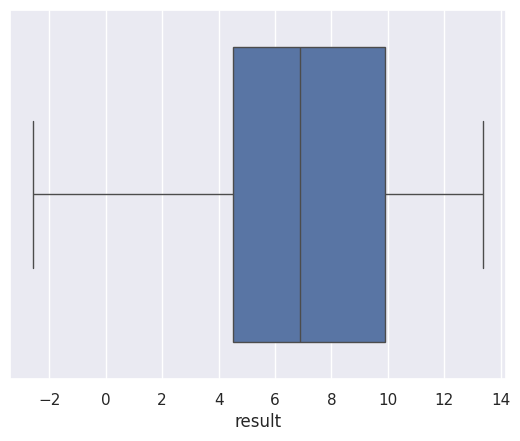

In [19]:
sns.boxplot(x=df['result'])
plt.show()

In [20]:
#Finding IQR for age
Q1=df['age'].quantile(0.25)
Q3=df['age'].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR
Age_outliers=df[(df['age']<lower_bound)|(df['age']>upper_bound)]
len(Age_outliers)

43

### Univariate Analysis for Categorical Columns

In [21]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [22]:
categorical_columns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score','gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation']

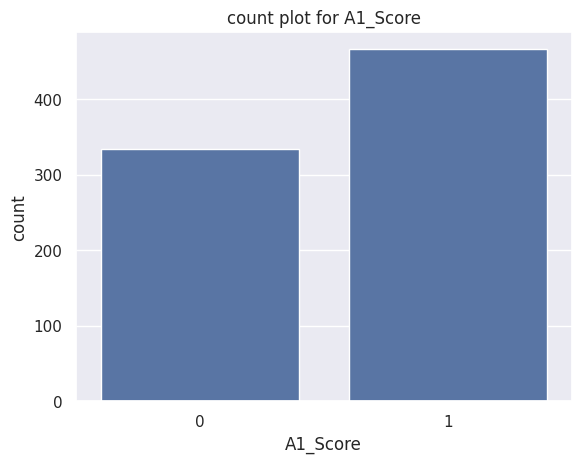

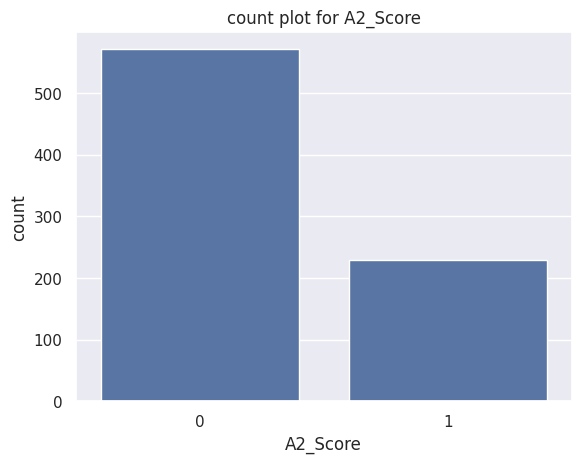

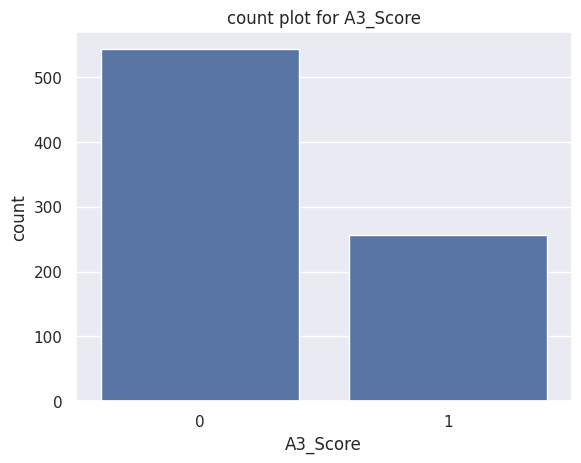

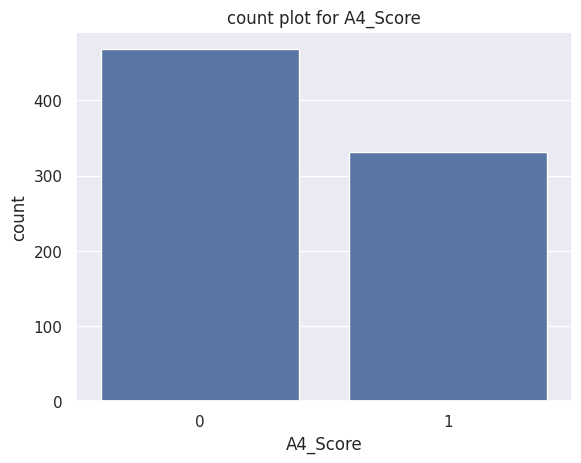

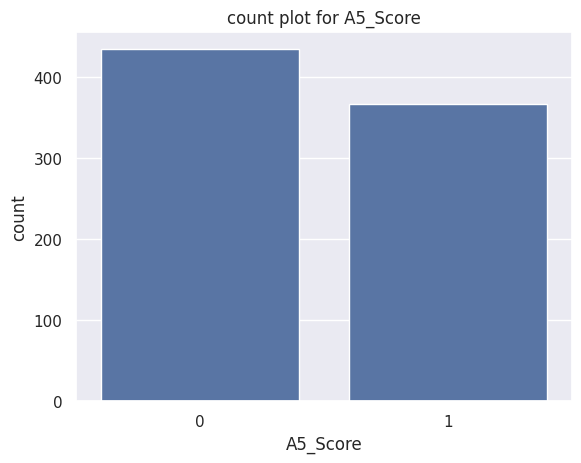

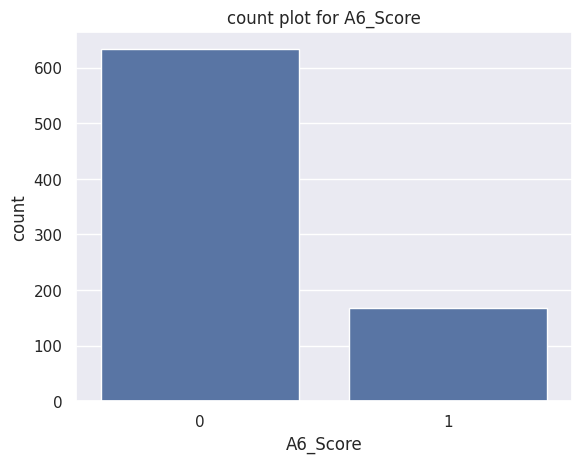

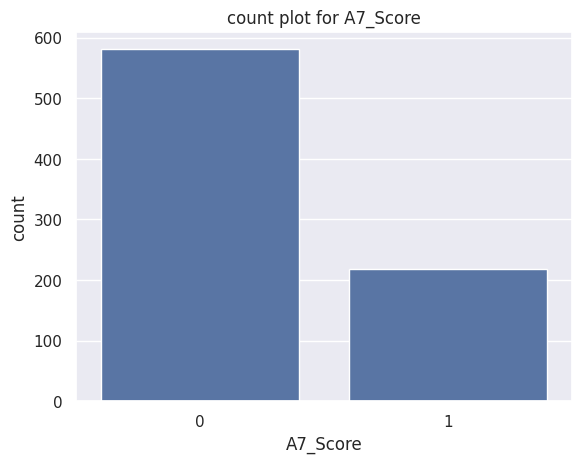

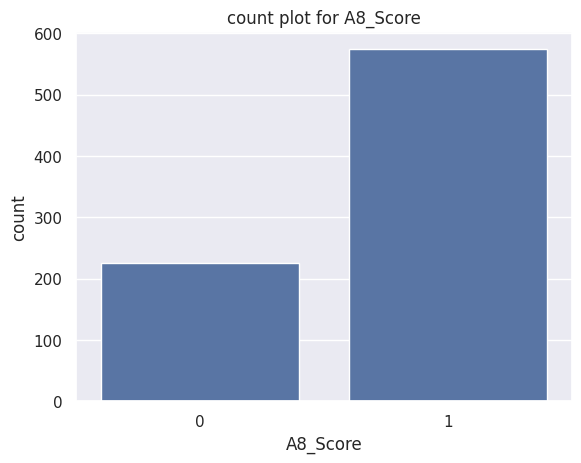

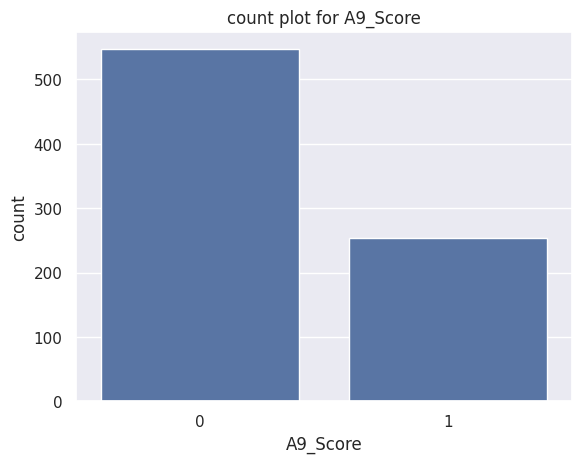

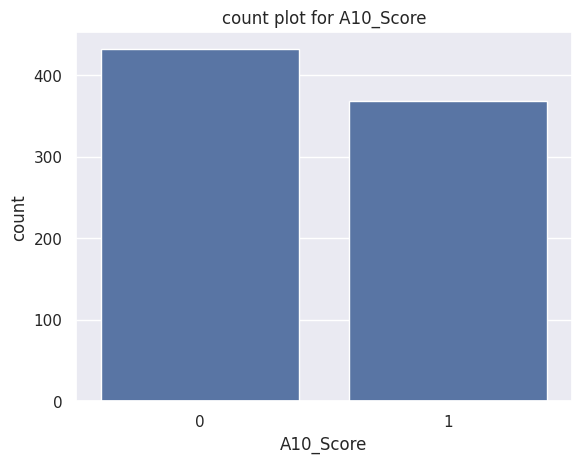

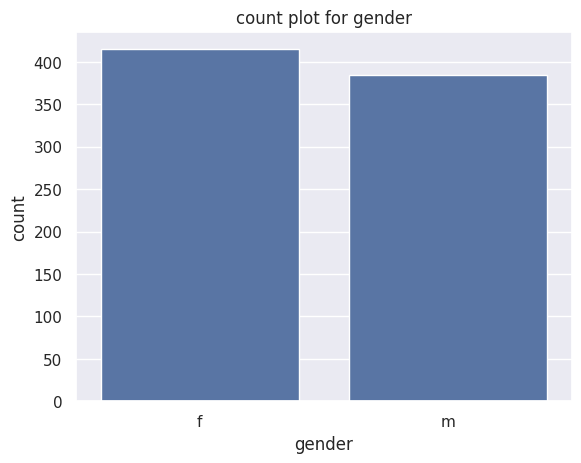

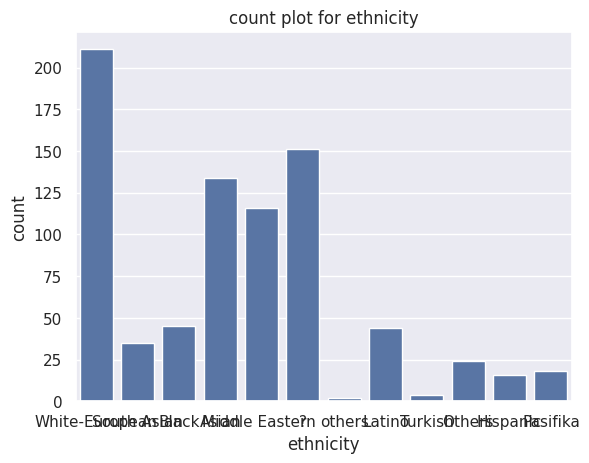

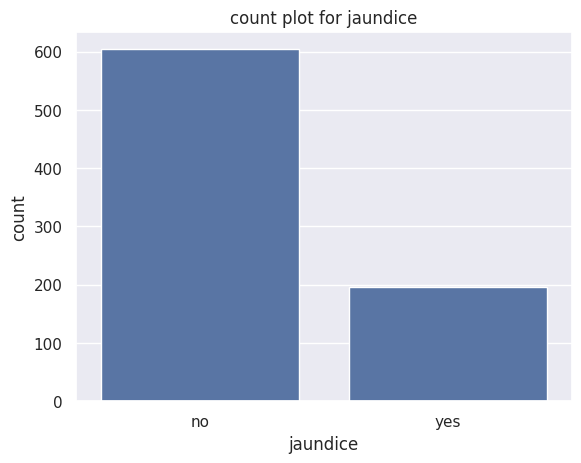

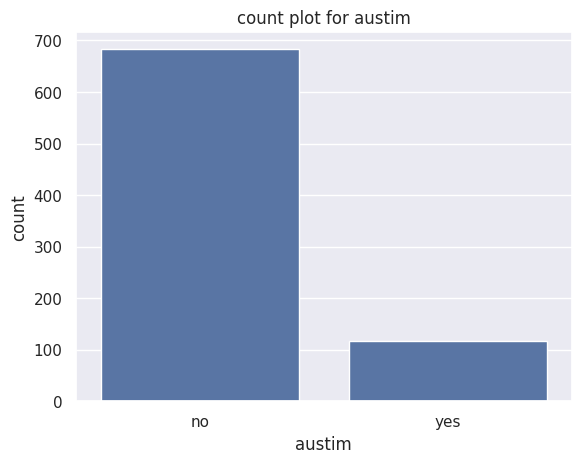

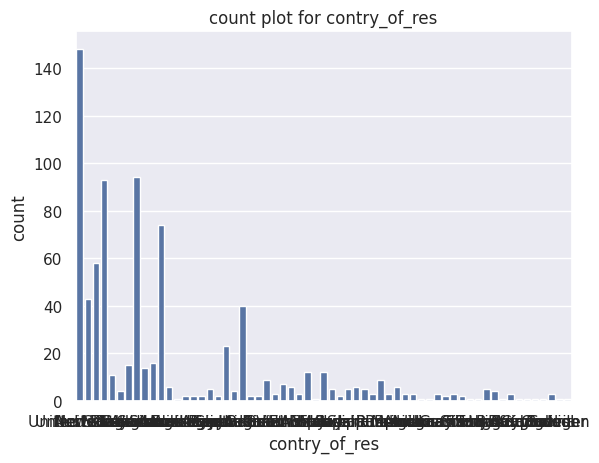

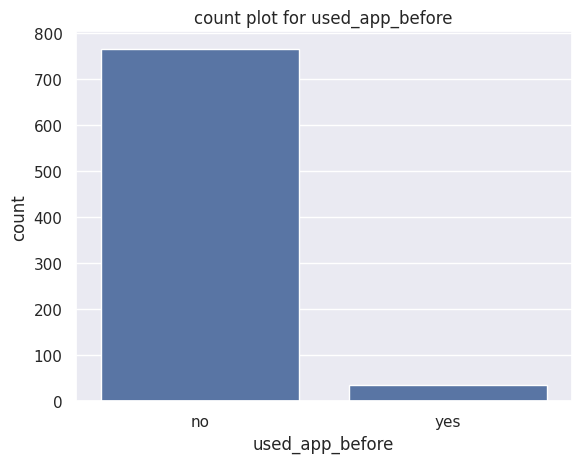

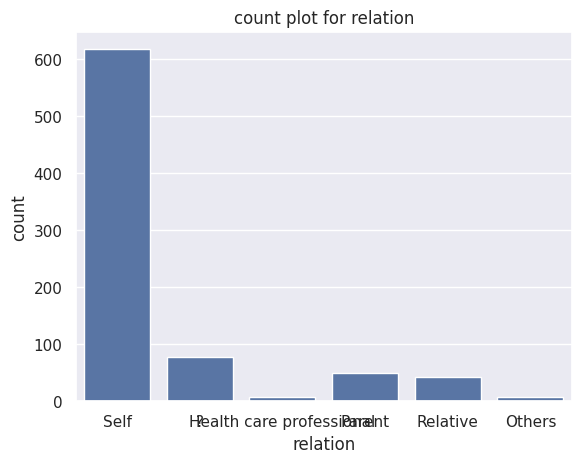

In [23]:
# Creating countplot to see frequency of categories
for col in categorical_columns:
  sns.countplot(x=df[col])
  plt.title(f'count plot for {col}')
  plt.xlabel(col)
  plt.ylabel('count')
  plt.show()

In [24]:
#Handling missing and duplicate values in ethnicity column
df['ethnicity']=df['ethnicity'].replace({'?':'Others','others':'Others'})

In [25]:
# converting relation into self and others instead of so many categories.
df['relation']=df['relation'].replace(
    {
        '?':'Others',
        'Health care professional':'Others',
        'Parent':'Others',
        'Relative':'Others'
    }
)

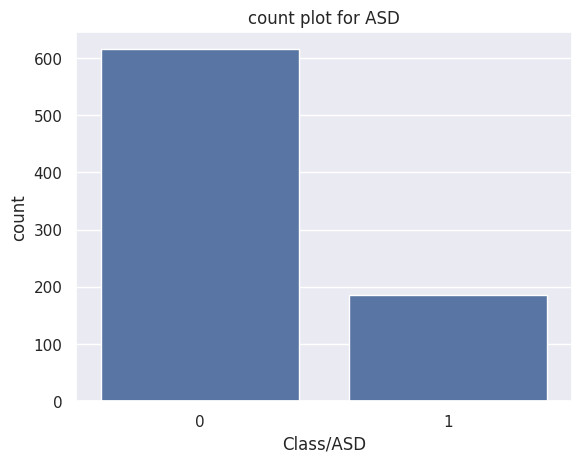

In [26]:
sns.countplot(x=df['Class/ASD'])
plt.title(f'count plot for ASD')
plt.xlabel('Class/ASD')
plt.ylabel('count')
plt.show()

We have a class imbalance here.

## Label Encoding

In [27]:
# we apply this to columns with 'object' data type.
object_columns=df.select_dtypes(include=['object']).columns
object_columns

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')

We see gender,ethnicity,jaundice,autism,country_of_res,used_app_before,relation all have object data type.

In [28]:
encoders={}
for col in object_columns:
  label_encoder=LabelEncoder()
  df[col]=label_encoder.fit_transform(df[col])
  encoders[col]=label_encoder
#save encoders
with open('encoders.pkl','wb') as f:
  pickle.dump(encoders,f)

In [29]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

## Bivariate Analysis

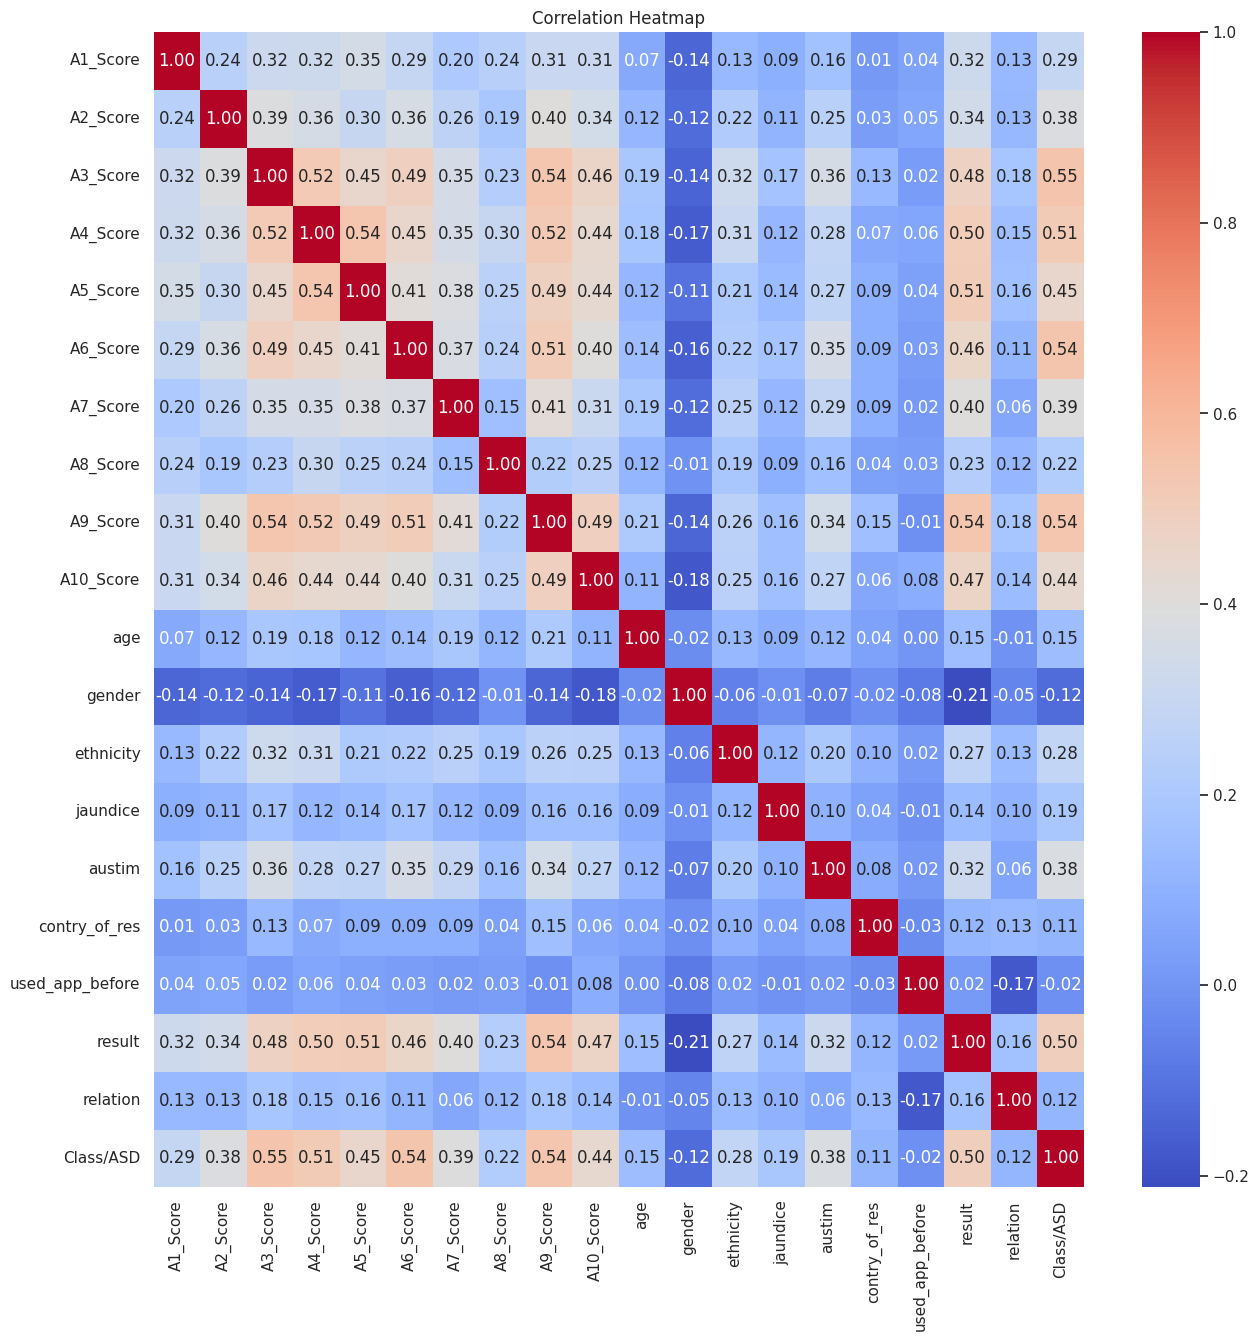

In [30]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Conclusion we derived from EDA:
1. There are outliers in Age column
2. Class imbalance in target column
3. Class imbalance in categorical features
4. No Highly correlated columns are there.
5. Label Encoders are created and saved.

In [31]:
# Function to fix outliers
def replace_outliers_with_median(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  upper_bound=Q3+1.5*IQR
  lower_bound=Q1-1.5*IQR
  median=df[column].median()
  df[column]=df[column].apply(lambda x:median if x>upper_bound or x < lower_bound else x)
  return df
df=replace_outliers_with_median(df,'age')


**Train Test Split**

In [32]:
x=df.drop(columns=['Class/ASD'])
y=df['Class/ASD']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [34]:
y_train.value_counts()

,count
Class/ASD,
0,494
1,146


In [35]:
y_test.value_counts()

,count
Class/ASD,
0,121
1,39


## SMOTE (Synthetic Minority Oversampling Technique)

In [36]:
smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

## Model Training

In [37]:
models={
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'XGBoost':XGBClassifier(random_state=42)
}

In [38]:
cv_scores={}
for model_name,model in models.items():
  print(f'Training{model_name} with default parameters')
  scores=cross_val_score(model,x_train_smote,y_train_smote,cv=5,scoring='accuracy')
  cv_scores[model_name]=scores
  print(f'{model_name} cross validation Accuracy : {np.mean(scores):.2f}')

TrainingDecision Tree with default parameters
Decision Tree cross validation Accuracy : 0.82
TrainingRandom Forest with default parameters
Random Forest cross validation Accuracy : 0.89
TrainingXGBoost with default parameters
XGBoost cross validation Accuracy : 0.89


In [39]:
cv_scores

{'Decision Tree': array([0.79292929, 0.82828283, 0.84343434, 0.81218274, 0.82233503]),
 'Random Forest': array([0.88383838, 0.85858586, 0.8989899 , 0.91370558, 0.90862944]),
 'XGBoost': array([0.84848485, 0.86868687, 0.91919192, 0.9035533 , 0.92385787])}

## Model Selection and Hyperparameter Tuning

In [40]:
Decision_Tree =DecisionTreeClassifier(random_state=42)
Random_Forest =RandomForestClassifier(random_state=42)
XGBoost_classifier= XGBClassifier(random_state=42)

In [41]:
# hyperparameter tuning for 3 model that can be automated later

hpara_grid_dt={
    'criterion':['gini','entropy'],
    'max_depth':[None,10,20,30,50,70],
     'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
hpara_grid_rf={
    'n_estimators':[50,100,200,500],
    'max_depth':[None,10,20,30],
     'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'bootstrap':[True,False]
}
hpara_grid_xgb={
   'n_estimators':[50,100,200,500],
    'max_depth':[3,5,7,10],
     'learning_rate':[0.01,0.1,0.2,0.3],
   'subsample':[0.5,0.7,1.0],
   'colsample_bytree':[0.5,0.7,1.0]
}

random_search_dt=RandomizedSearchCV(estimator=Decision_Tree,param_distributions=hpara_grid_dt,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_search_rf=RandomizedSearchCV(estimator=Random_Forest,param_distributions=hpara_grid_rf,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_search_xgb=RandomizedSearchCV(estimator=XGBoost_classifier,param_distributions=hpara_grid_xgb,n_iter=10,cv=5,scoring='accuracy',random_state=42)
random_search_dt.fit(x_train_smote,y_train_smote)
random_search_rf.fit(x_train_smote,y_train_smote)
random_search_xgb.fit(x_train_smote,y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [42]:
print(random_search_dt.best_estimator_)

DecisionTreeClassifier(max_depth=70, random_state=42)


In [43]:
print(random_search_rf.best_estimator_)

RandomForestClassifier(bootstrap=False, max_depth=10, random_state=42)


In [44]:
print(random_search_xgb.best_estimator_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


In [45]:
#Finding Model With Best Score
best_model=None
best_score=0
if random_search_dt.best_score_>best_score:
  best_model=random_search_dt.best_estimator_
  best_score=random_search_dt.best_score_

if random_search_rf.best_score_>best_score:
  best_model=random_search_rf.best_estimator_
  best_score=random_search_rf.best_score_

if random_search_xgb.best_score_>best_score:
  best_model=random_search_xgb.best_estimator_
  best_score=random_search_xgb.best_score_

In [46]:
print(f'Best model is: {best_model}')
print(f'Best CV Accuracy is: {best_score:.2f}')

Best model is: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)
Best CV Accuracy is: 0.89


In [47]:
with open('best_model.pkl','wb') as f:
  pickle.dump(best_model,f)

## Model Evaluation

In [48]:
y_test_pred=best_model.predict(x_test)
print('Accuracy score:\n',accuracy_score(y_test,y_test_pred))
print('Confusion Matrix:\n',confusion_matrix(y_test,y_test_pred))
print('classification_repot:\n',classification_report(y_test,y_test_pred))

Accuracy score:
 0.78125
Confusion Matrix:
 [[97 24]
 [11 28]]
classification_repot:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85       121
           1       0.54      0.72      0.62        39

    accuracy                           0.78       160
   macro avg       0.72      0.76      0.73       160
weighted avg       0.81      0.78      0.79       160



# Autism Predictor Output

In [50]:
import pickle
import pandas as pd

with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)


def predict_autism(data_dict):

    input_df = pd.DataFrame([data_dict])

    for column, encoder in encoders.items():
        if column in input_df.columns:

            value = input_df[column].iloc[0]

            if value in encoder.classes_:
                input_df[column] = encoder.transform(input_df[column])
            else:
                input_df[column] = -1

    prediction = best_model.predict(input_df)[0]

    if prediction == 1:
        return "Autism Likely"
    else:
        return "Autism Not Likely"


sample_input = {
    'A1_Score': 1,
    'A2_Score': 1,
    'A3_Score': 0,
    'A4_Score': 1,
    'A5_Score': 0,
    'A6_Score': 1,
    'A7_Score': 1,
    'A8_Score': 0,
    'A9_Score': 1,
    'A10_Score': 1,
    'age': 25,
    'gender': 'm',
    'ethnicity': 'White-European',
    'jaundice': 'no',
    'austim': 'no',
    'contry_of_res': 'India',
    'used_app_before': 'no',
    'result': 6,
    'relation': 'Self'
}

result = predict_autism(sample_input)
print(result)

Autism Not Likely
